## SUPPLEMENTARY FIGURES 1 and 3 FOR WUS WARMING PAPER

In [1]:
import netCDF4
#import h5netcdf
import xarray as xr
import scipy
import os
import numpy as np
import xeofs as xeo
import scipy.stats as stats
import warnings
import matplotlib.pyplot as plt
import scipy.signal as signal
import pandas as pd
import cartopy.crs as ccrs
import cartopy
import seaborn as sns
import xskillscore as xsc


def fix_coords_lon(ds):
    ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180)).sortby(['longitude','latitude'])
    return ds

def fix_coords_lon_lat(ds):
    ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby(['lon','lat'])
    return ds

import cftime
def to_dt64(ds, timevar='time', unit='months since 1979-01-01'):
    ds[timevar] = cftime.num2date(ds[timevar], unit, '360_day')
    ds[timevar] = ds.indexes[timevar].to_datetimeindex()
    return ds

wusbox = [-125, -102, 32,  49]


## Open CMIP6 LWD data

In [2]:
ds_lwd_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_lwd_avgs.nc')

ds_lwd_avg_51_80_m_clim = ds_lwd_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_lwd_avg_51_80_m_anom = ds_lwd_avg.groupby('time.month') - ds_lwd_avg_51_80_m_clim

ds_lwd_avg_51_80_m_anom_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_avg_51_80_m_anom_szn[szn] = ds_lwd_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    
ds_lwd_avg_51_80_m_anom_trend_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_avg_51_80_m_anom_trend_szn[szn] = ds_lwd_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)


In [3]:
ds_lwd_clr_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_rldscs_avgs.nc')

ds_lwd_clr_avg_51_80_m_clim = ds_lwd_clr_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_lwd_clr_avg_51_80_m_anom = ds_lwd_clr_avg.groupby('time.month') - ds_lwd_clr_avg_51_80_m_clim

ds_lwd_clr_avg_51_80_m_anom_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_clr_avg_51_80_m_anom_szn[szn] = ds_lwd_clr_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    
ds_lwd_clr_avg_51_80_m_anom_trend_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_lwd_clr_avg_51_80_m_anom_trend_szn[szn] = ds_lwd_clr_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)


## Open ERA5 data

In [4]:
era5_lwd_clr = (1/86400)*xr.open_dataset('/d4/tessj/data/ERA5/single_level/monthly/ds_slwd_clr_1940_2025.nc')
era5_lwd_clr = fix_coords_lon(era5_lwd_clr).rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'}).sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2], wusbox[3])).drop(['number', 'expver']).load()
era5_lwd_clr_jfm = era5_lwd_clr.resample(time='QS-JAN').mean('time').isel(time=slice(0,None,4)).groupby('time.year').mean('time')

In [5]:
era5_clt = xr.open_dataset('/d4/tessj/data/ERA5/single_level/monthly/ds_tcc_1940_2025.nc')
era5_clt = fix_coords_lon(era5_clt).rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'}).sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2], wusbox[3])).drop(['number', 'expver']).load()
era5_clt_jfm = era5_clt.resample(time='QS-JAN').mean('time').isel(time=slice(0,None,4)).groupby('time.year').mean('time')

In [6]:
era5_lwd = xr.open_dataset('/d4/tessj/data/ERA5/single_level/monthly/ds_msdwlwrf_1940_2025.nc')
era5_lwd = fix_coords_lon(era5_lwd).rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'}).sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2], wusbox[3])).drop(['number', 'expver']).load()
era5_lwd_jfm = era5_lwd.resample(time='QS-JAN').mean('time').isel(time=slice(0,None,4)).groupby('time.year').mean('time')

In [7]:
landmask_era5 = fix_coords_lon(xr.open_dataarray('/home/tessj/wildfire-clim/land_sea_mask.nc').isel(time=-1).load()).rename({'latitude':'lat', 'longitude':'lon'}).drop(['expver','time'])
landmask_era5 = landmask_era5.where(landmask_era5>0.4, np.nan)
landmask_era5 = landmask_era5/landmask_era5

In [8]:
era5_weights = np.cos(np.deg2rad(era5_lwd_jfm.lat))
era5_wusavg_lwd = era5_lwd_jfm.where(landmask_era5==landmask_era5).weighted(era5_weights).mean(['lat','lon']).sel(year=slice(1980,2024)).avg_sdlwrf.values

In [9]:
era5_wusavg_lwd_clr = era5_lwd_clr_jfm.where(landmask_era5==landmask_era5).weighted(era5_weights).mean(['lat','lon']).sel(year=slice(1980,2024)).strdc.values

In [10]:
# clear-sky ERA5 LWD trend
45*np.polyfit(era5_lwd_jfm.sel(year=slice(1980,2024)).year, era5_wusavg_lwd_clr, deg=1)[0]

0.7375459656228737

In [12]:
# all-sky ERA5 LWD trend
45*np.polyfit(era5_lwd_jfm.sel(year=slice(1980,2024)).year, era5_wusavg_lwd, deg=1)[0]

-1.7236339743753997

In [20]:
# total cloud cover ERA5 trend
era5_clt_jfm_trend = (45*era5_clt_jfm.sel(year=slice(1980,2024)).polyfit(dim='year', deg=1).sel(degree=1).tcc_polyfit_coefficients).where(landmask_era5==landmask_era5).weighted(era5_weights).mean(['lon','lat'])

In [101]:
era5_clt_jfm_trend

<xarray.DataArray 'tcc_polyfit_coefficients' ()>
array(-0.03241219)
Coordinates:
    degree   int64 1

### Open CMIP6 cloud cover data

In [21]:
cmip6_clt = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_clt_na.nc')


In [22]:
cmip6_clt_jfm = cmip6_clt.resample(time='QS-JAN').mean('time').isel(time=slice(0,None,4)).groupby('time.year').mean('time')

In [23]:
landmask_cmip6 = landmask_era5.interp_like(cmip6_clt.sel(lat=slice(32,49),lon=slice(-125,-102)))
weights_cmip6 = np.cos(np.deg2rad(landmask_cmip6.lat))

In [24]:
cmip6_clt_jfm_trend = (45*.01*cmip6_clt_jfm.sel(year=slice(1980,2024)).polyfit(dim='year', deg=1).sel(degree=1, lat=slice(32,49),lon=slice(-125,-102)).clt_polyfit_coefficients).where(landmask_cmip6==landmask_cmip6).weighted(weights_cmip6).mean(['lon','lat'])
cmip6_clt_jfm_trend

<xarray.DataArray 'clt_polyfit_coefficients' (model: 22)>
array([ 0.00550671, -0.00748475, -0.00012269, -0.01174102, -0.00061128,
       -0.00460355,  0.00984859, -0.01549738, -0.00297822, -0.00921207,
       -0.00674289,  0.01884397, -0.00065701, -0.01152453, -0.02956197,
       -0.02300234,  0.00014205, -0.02771383,  0.01691005,  0.0025885 ,
        0.00740064,  0.00182072])
Coordinates:
  * model    (model) object 'GFDL-ESM4' 'IPSL-CM6A-LR' ... 'EC-Earth3-Veg-LR'
    degree   int64 1

### Open CAM6 clouds/LWD 

In [26]:
cam6_ds_clt = fix_coords_lon_lat(xr.open_dataset('/d5/tessj/data/CAM6/clt_ens.nc')).sel(lat=slice(32,49),lon=slice(-125,-102))
cam6_ds_clt

<xarray.Dataset>
Dimensions:  (lat: 9, time: 512, lon: 10, member: 16)
Coordinates:
  * lat      (lat) float32 33.16 35.05 36.95 38.84 40.74 42.63 44.53 46.42 48.32
  * time     (time) datetime64[ns] 1979-01-16 1979-02-16 ... 2021-08-16
  * lon      (lon) float32 -125.0 -122.5 -120.0 -117.5 ... -107.5 -105.0 -102.5
  * member   (member) object '001' '002' '003' '004' ... '013' '014' '015' '016'
Data variables:
    CLDTOT   (member, time, lat, lon) float32 ...
Attributes:
    Conventions:  IRIDL

In [82]:
cam6_ds_lwd = fix_coords_lon_lat(xr.open_dataset('/d5/tessj/data/CAM6/lwd_ens.nc')).sel(lat=slice(32,49),lon=slice(-125,-102))
cam6_ds_lwd

<xarray.Dataset>
Dimensions:  (lat: 9, time: 512, lon: 10, member: 16)
Coordinates:
  * lat      (lat) float32 33.16 35.05 36.95 38.84 40.74 42.63 44.53 46.42 48.32
  * time     (time) datetime64[ns] 1979-01-16 1979-02-16 ... 2021-08-16
  * lon      (lon) float32 -125.0 -122.5 -120.0 -117.5 ... -107.5 -105.0 -102.5
  * member   (member) object '001' '002' '003' '004' ... '013' '014' '015' '016'
Data variables:
    FLDS     (member, time, lat, lon) float32 ...
Attributes:
    Conventions:  IRIDL

In [31]:
landmask_cam6 = landmask_era5.interp_like(cam6_ds_clt.sel(lat=slice(32,49),lon=slice(-125,-102)))
weights_cam6 = np.cos(np.deg2rad(cam6_ds_clt.lat))

In [32]:
cam6_clt_jfm = cam6_ds_clt.resample(time='QS-JAN').mean('time').isel(time=slice(0,None,4)).groupby('time.year').mean('time')

In [86]:
cam6_lwd_jfm = cam6_ds_lwd.resample(time='QS-JAN').mean('time').isel(time=slice(0,None,4)).groupby('time.year').mean('time')

In [34]:
cam6_clt_jfm_trend = (45*100*cam6_clt_jfm.sel(year=slice(1980,2021)).polyfit(dim='year', deg=1).sel(degree=1, lat=slice(32,49),lon=slice(-125,-102)).CLDTOT_polyfit_coefficients).where(landmask_cam6==landmask_cam6).weighted(weights_cam6).mean(['lon','lat'])
cam6_clt_jfm_trend

<xarray.DataArray 'CLDTOT_polyfit_coefficients' (member: 16)>
array([-1.80738721,  0.96283113, -2.40283969, -3.37467785,  0.02626554,
        0.69339514, -2.15271356, -1.13066576, -0.49140028,  2.27441578,
       -2.35699518, -2.99273615, -2.09742969, -0.97401815,  0.28046086,
       -2.14642012])
Coordinates:
  * member   (member) object '001' '002' '003' '004' ... '013' '014' '015' '016'
    degree   int64 1

In [87]:
cam6_lwd_jfm_trend = (45*cam6_lwd_jfm.sel(year=slice(1980,2021)).polyfit(dim='year', deg=1).sel(degree=1, lat=slice(32,49),lon=slice(-125,-102)).FLDS_polyfit_coefficients).where(landmask_cam6==landmask_cam6).weighted(weights_cam6).mean(['lon','lat'])
cam6_lwd_jfm_trend

<xarray.DataArray 'FLDS_polyfit_coefficients' (member: 16)>
array([ 7.945367  , 10.64907667,  5.63632317,  4.34440215,  5.85605689,
        7.69407272,  5.28922443,  5.95953093,  5.54531722, 11.06685934,
        5.99563134,  4.99133751,  7.27157717,  6.62624   ,  7.12747115,
        7.47930722])
Coordinates:
  * member   (member) object '001' '002' '003' '004' ... '013' '014' '015' '016'
    degree   int64 1

### Open CLARA Satellite clouds data (from https://cds.climate.copernicus.eu/datasets/satellite-cloud-properties?tab=overview)

“CLARA (CM SAF cLoud, Albedo and surface Radiation) product family” originates in the European Organisation for the Exploitation of Meteorological Satellites (EUMETSAT) Satellite Application Facility on Climate Monitoring (CM SAF), who produced a TCDR based on AVHRR observations.

In [36]:
#clara_obs_test = xr.open_dataset('/d5/tessj/data/CLARA-A3/CFCmm20201201000000319AVPOS01GL.nc')

In [37]:
#import os
#clara_nc_list = os.listdir('/d5/tessj/data/CLARA-A3/')
#clara_nc_list = [f'/d5/tessj/data/CLARA-A3/{file}' for file in clara_nc_list if ((file[-3:]=='.nc') & (file[:5]'CFCmm'))]
#clara_obs = xr.open_mfdataset(clara_nc_list).sel(lat=slice(32,49),lon=slice(-125,-102))
#clara_obs = clara_obs.cfc.load()
#clara_obs.to_netcdf('/d5/tessj/data/CLARA-A3/cfc_wus_1980_2020.nc')

In [38]:
clara_obs = xr.open_dataset('/d5/tessj/data/CLARA-A3/cfc_wus_1980_2020.nc')

In [39]:
clara_obs_jfm = clara_obs.resample(time='QS-JAN').mean('time').isel(time=slice(0,None,4)).groupby('time.year').mean('time')


In [40]:
landmask_clara = landmask_era5.interp_like(clara_obs_jfm)
weights_clara = np.cos(np.deg2rad(clara_obs_jfm.lat))

In [44]:
clara_clt_jfm_trend = (45*clara_obs_jfm.sel(year=slice(1980,2020)).polyfit(dim='year', deg=1).sel(degree=1, lat=slice(32,49),lon=slice(-125,-102)).cfc_polyfit_coefficients).where(landmask_clara==landmask_clara).weighted(weights_clara).mean(['lon','lat'])
clara_clt_jfm_trend

<xarray.DataArray 'cfc_polyfit_coefficients' ()>
array(-9.52155248)
Coordinates:
    degree   int64 1

In [45]:
# correlation between LWD trends and cloud cover trends
xr.corr(45*ds_lwd_avg_51_80_m_anom_trend_szn['JFM'].lwd_wus_polyfit_coefficients, 100*cmip6_clt_jfm_trend.sel(model=ds_lwd_avg_51_80_m_anom_trend_szn['JFM'].model))

<xarray.DataArray ()>
array(0.60840357)
Coordinates:
    degree   int64 1

### Plot figure S3 left panel

Text(0, 0.5, 'Cloud cover trend (%/45 years)')

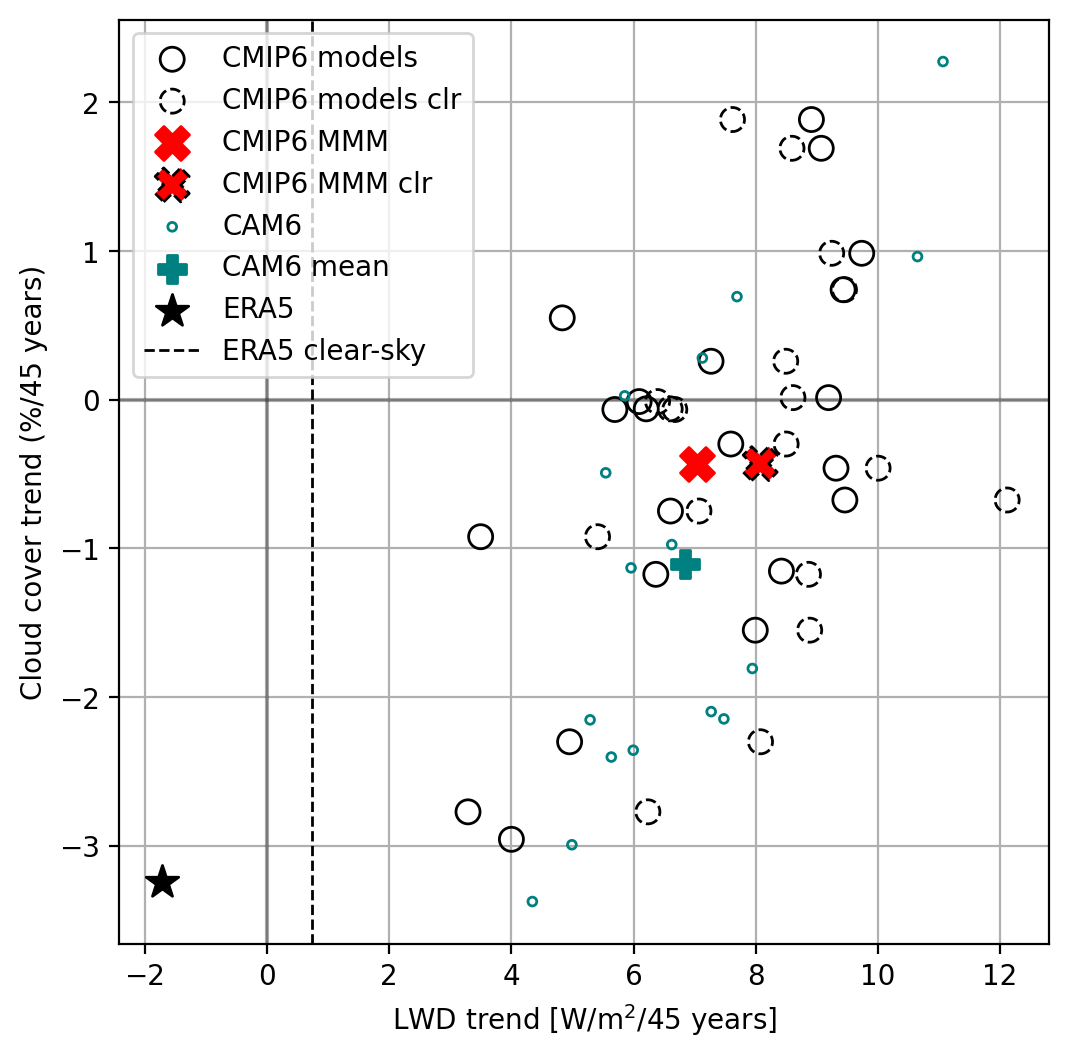

In [167]:

plt.figure(figsize=(6,6), dpi=200)
ax = plt.subplot(1,1,1)
ax.grid(zorder=-10)

calc_model_mean = []
for model in ds_lwd_avg_51_80_m_anom_trend_szn['JFM'].model.values:
    if model=='CESM2':
        ax.scatter(45*ds_lwd_avg_51_80_m_anom_trend_szn['JFM'].sel(model=model).lwd_wus_polyfit_coefficients, 100*cmip6_clt_jfm_trend.sel(model=model), marker='o',
            facecolor='None', edgecolors='k', label='CMIP6 models', s=75, zorder=5)
    else:
        ax.scatter(45*ds_lwd_avg_51_80_m_anom_trend_szn['JFM'].sel(model=model).lwd_wus_polyfit_coefficients, 100*cmip6_clt_jfm_trend.sel(model=model), marker='o',
            facecolor='None', edgecolors='k', s=75, zorder=5)
    calc_model_mean.append(cmip6_clt_jfm_trend.sel(model=model).item())
    

for model in modmembers_lwd_all.keys():
    if model=='CESM2':
        ax.scatter(45*ds_lwd_clr_avg_51_80_m_anom_trend_szn['JFM'].sel(model=model).rldscs_wus_polyfit_coefficients, 100*cmip6_clt_jfm_trend.sel(model=model), marker='o',
            facecolor='None', edgecolors='k',ls='--', label='CMIP6 models clr', s=75, zorder=5)
    else:
        ax.scatter(45*ds_lwd_clr_avg_51_80_m_anom_trend_szn['JFM'].sel(model=model).rldscs_wus_polyfit_coefficients, 100*cmip6_clt_jfm_trend.sel(model=model), marker='o',
            facecolor='None', edgecolors='k',ls='--', s=75, zorder=5)
    
ax.scatter(y=100*np.nanmean(calc_model_mean), x=45*ds_lwd_avg_51_80_m_anom_trend_szn['JFM'].lwd_wus_polyfit_coefficients.mean('model'),
          c='r', marker='X', s=150, label='CMIP6 MMM', zorder=5)

ax.scatter(y=100*np.nanmean(calc_model_mean), x=45*ds_lwd_clr_avg_51_80_m_anom_trend_szn['JFM'].rldscs_wus_polyfit_coefficients.mean('model'),
          facecolor='r', edgecolors='k',ls='--',  marker='X', s=150, label='CMIP6 MMM clr', zorder=5)

ax.scatter(x=cam6_lwd_jfm_trend, y =cam6_clt_jfm_trend, s=10, marker='o',
            facecolor='None', edgecolors='teal',zorder=20, label = 'CAM6')
ax.scatter(x=cam6_lwd_jfm_trend.mean('member'), y =cam6_clt_jfm_trend.mean('member'), c='teal', marker='P', s=100, label='CAM6 mean')
    
#for model in modmembers_lwd_all:
#    for member_id in modmembers_lwd_all[model]:
#        x=cmip6_lwd.sel(model=model, member_id = member_id).polyfit(dim='year', deg=1).sel(degree=1).rlds_polyfit_coefficients
#        y=cmip6_lwd_clr.sel(model=model, member_id = member_id).polyfit(dim='year', deg=1).sel(degree=1).rldscs_polyfit_coefficients
#        plt.scatter(45*x, 45*y)

ax.scatter(y=100*era5_clt_jfm_trend, x=45*np.polyfit(era5_lwd_jfm.sel(year=slice(1980,2024)).year, era5_wusavg_lwd, deg=1)[0],
          c='k', marker='*', s=150, label='ERA5', zorder=5)


#ax.plot(np.arange(-10,20),np.arange(-10,20), zorder=2,c='grey',ls='--',label='1:1')

ax.axhline(0, c='k', lw=1.5, alpha=0.3)
ax.axvline(0, c='k', lw=1.5, alpha=0.3)
ax.axvline(45*np.polyfit(era5_lwd_jfm.sel(year=slice(1980,2024)).year, era5_wusavg_lwd_clr, deg=1)[0], lw=1, ls='--', c='k', label='ERA5 clear-sky')

#ax.set_ylim(-1,2)
#ax.set_xlim(-4,11)
ax.legend()
ax.set_xlabel('LWD trend [W/m$^2$/45 years]')

ax.set_ylabel('Cloud cover trend (%/45 years)')

In [254]:
era5_cloud_lwd = 45*np.polyfit(era5_lwd_jfm.sel(year=slice(1980,2024)).year, era5_wusavg_lwd, deg=1)[0] - 45*np.polyfit(era5_lwd_jfm.sel(year=slice(1980,2024)).year, era5_wusavg_lwd_clr, deg=1)[0]

-2.4611799399982734

In [258]:
# cloud bias contr
((-1*era5_cloud_lwd) - (45*ds_lwd_clr_avg_51_80_m_anom_trend_szn['JFM'].rldscs_wus_polyfit_coefficients - 45*ds_lwd_avg_51_80_m_anom_trend_szn['JFM'].lwd_wus_polyfit_coefficients)).sel(model = ['CNRM-CM6-1', 'IPSL-CM6A-LR', 'EC-Earth3-Veg', 'CanESM5-CanOE', 'MIROC6', 'MRI-ESM2-0', 'MPI-ESM1-2-LR', 'FIO-ESM-2-0', 'FGOALS-g3', 'EC-Earth3', 'CESM2', 'CESM2-WACCM', 'MIROC-ES2L', 'CNRM-ESM2-1', 'CanESM5', 'KACE-1-0-G', 'UKESM1-0-LL'])

<xarray.DataArray (model: 17)>
array([ 2.15923548,  1.99512433,  2.94009748,  2.95291983,  1.55568934,
       -0.03763664,  0.54788873,  3.04509625,  3.75320442,  1.2389976 ,
        2.43882863, -0.19557265,  1.48011067,  2.0694591 ,  1.77261594,
       -0.66370547,  1.57071678])
Coordinates:
  * model    (model) object 'CNRM-CM6-1' 'IPSL-CM6A-LR' ... 'UKESM1-0-LL'
    degree   int64 1

### open CMIP6 LWD trends used in pyRTE analysis

In [5]:
cmip6_lwd = xr.open_dataset('/d5/tessj/data/CMIP6/for_tess/WUS_subset_forpyrte/rlds_WUSavg_19800101-20241231_allmodels.nc').resample(time='QS-JAN').mean('time').isel(time=slice(0,None,4)).groupby('time.year').mean('time')
cmip6_lwd_clr = xr.open_dataset('/d5/tessj/data/CMIP6/for_tess/WUS_subset_forpyrte/rldscs_WUSavg_19800101-20241231_allmodels.nc').resample(time='QS-JAN').mean('time').isel(time=slice(0,None,4)).groupby('time.year').mean('time')


In [6]:
# get all ensemble members
modmembers_lwd_all = {}
for model in cmip6_lwd.model:
    if model.item() in cmip6_lwd_clr.model:
        modmembers_lwd_all[model.item()] = []
        for member_id in cmip6_lwd.sel(model=model).dropna(dim='member_id').member_id:
            if member_id.item() in cmip6_lwd_clr.sel(model=model).dropna(dim='member_id').member_id:
                modmembers_lwd_all[model.item()].append(member_id.item())
                

In [7]:
# open clear-sky LWD trends calculated by pyRTE
cmip6_pyrte_clr_lwd_trend = []
for model in modmembers_lwd_all :
    print(model)
    cmip6_pyrte_clr_lwd_trend.append(
        xr.open_dataset(f'/home/tessj/wus_temp_trends/pyRTE-RRTMGP/examples/CMIP6_LWD_sfc_clr/{model}_lwd_members.nc').polyfit(dim='year', deg=1).sel(degree=1).h2o_polyfit_coefficients.assign_coords(model=model))


CNRM-CM6-1
IPSL-CM6A-LR
EC-Earth3-Veg
CanESM5-CanOE
MIROC6
MRI-ESM2-0
MPI-ESM1-2-LR
FIO-ESM-2-0
ACCESS-CM2
FGOALS-g3
EC-Earth3
CESM2
CESM2-WACCM
MIROC-ES2L
CNRM-ESM2-1
CanESM5
KACE-1-0-G
UKESM1-0-LL
GISS-E2-1-G


In [8]:
cmip6_pyrte_clr_lwd_trend_ds = xr.concat(cmip6_pyrte_clr_lwd_trend, dim='model')

### Plot supplementary S1

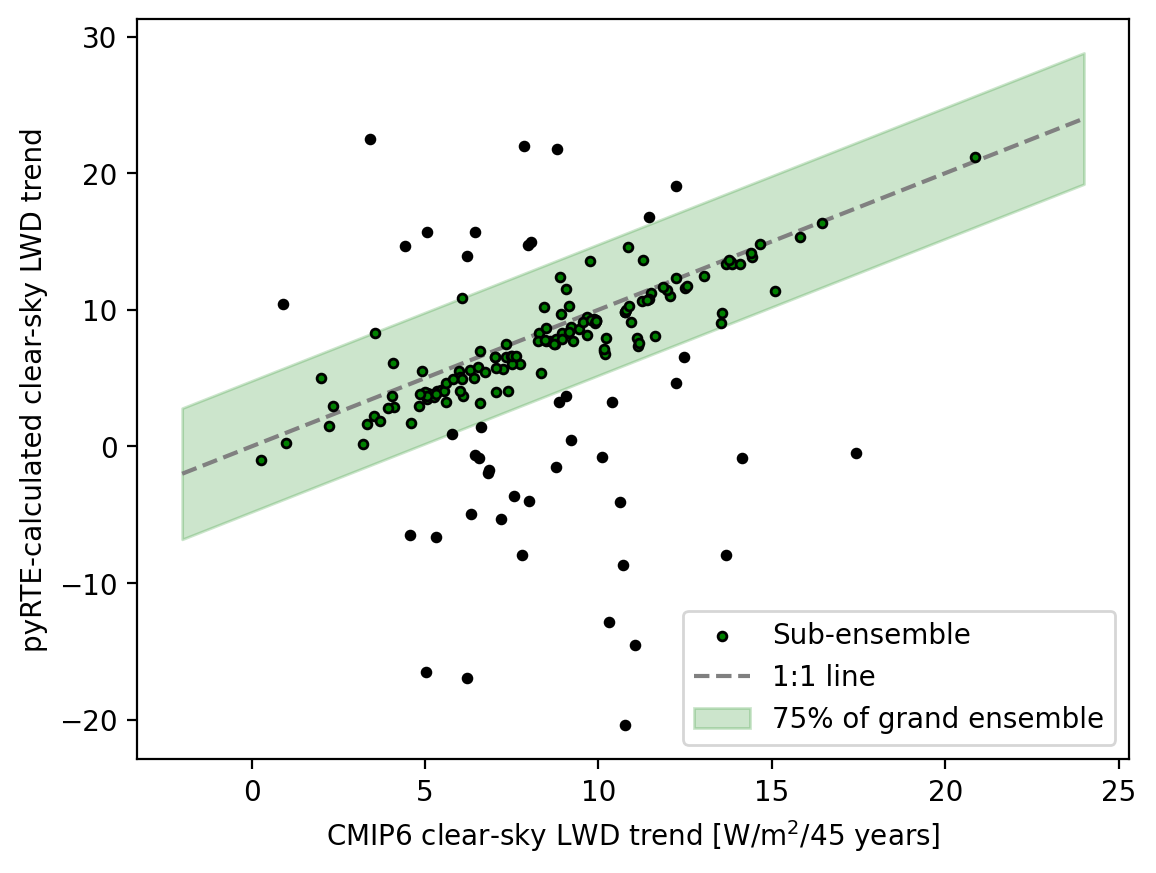

In [38]:
plt.subplots(1,1, dpi=200)
membercount_total = 0 # total non-nan ens members 
membercount = 0 # ens members with pyrte modeled lwd trends very far from the observed trend
models_valid = [] # models with any ens members where pyrte trend is close to observed trend
modmembers_valid = {}
subenslabel=0
for model in modmembers_lwd_all:
    modmembers_valid[model] = []
    for member_id in modmembers_lwd_all[model]:
        y=cmip6_pyrte_clr_lwd_trend_ds.sel(model=model, member_id = member_id)
        x=cmip6_lwd_clr.sel(model=model, member_id = member_id).polyfit(dim='year', deg=1).sel(degree=1).rldscs_polyfit_coefficients
        if np.abs(45*y - 45*x) <= 4.8:
            if subenslabel==0:
                plt.scatter(45*x, 45*y, s=10, c='g',edgecolor='k', linewidth=1, label='Sub-ensemble')
                subenslabel=1
            else:
                plt.scatter(45*x, 45*y, s=10,c='g',edgecolor='k', linewidth=1,)

            membercount_total += 1
            models_valid.append(model)
            modmembers_valid[model].append(member_id)
        # make sure to skip nans here
        elif np.abs(45*y - 45*x) == np.abs(45*y - 45*x):
            plt.scatter(45*x, 45*y, s=10, c='k')
            membercount+=1
            membercount_total+=1
plt.plot(np.arange(-2,25), np.arange(-2, 25), label='1:1 line', c='grey', ls='--',zorder=0)
plt.fill_between(np.arange(-2,25), np.arange(-2, 25) - 4.8, np.arange(-2, 25) + 4.8, color='g', alpha=0.2, label='75% of grand ensemble', zorder=-1)

plt.xlabel('CMIP6 clear-sky LWD trend [W/m$^2$/45 years]')
plt.ylabel('pyRTE-calculated clear-sky LWD trend')
plt.legend()

In [273]:
# models missing from models_valid
set(np.unique(models_valid)) ^ set(modmembers_lwd_all.keys())

{'GISS-E2-1-G'}

In [22]:
# fraction of all non-nan members that are excluded
membercount/membercount_total

0.24855491329479767

In [275]:
# save out dict of valid model members
import json
json.dump(modmembers_valid, open('/home/tessj/wus_temp_trends/modmembers_trendwithin5wm2_pyrte_lwd_clr.json', 'w'))

### plot JFM cloud fraction trends (Supplemental figure 3, right panel)

In [61]:
era5_clt_jfm_trend_plot = (45*100*era5_clt_jfm.sel(year=slice(1980,2024)).polyfit(dim='year', deg=1).sel(degree=1).tcc_polyfit_coefficients)#.plot()
clara_clt_jfm_trend_plot = (45*clara_obs_jfm.polyfit(dim='year', deg=1).sel(degree=1).cfc_polyfit_coefficients)#.plot()
cmip6_clt_jfm_trend_plot = (45*cmip6_clt_jfm.mean('model').sel(year=slice(1980,2024)).polyfit(dim='year', deg=1).sel(degree=1, lat=slice(32,49),lon=slice(-125,-102)).clt_polyfit_coefficients)
cam6_clt_jfm_trend_plot = (45*100*cam6_clt_jfm.sel(year=slice(1980,2021)).mean('member')).polyfit(dim='year', deg=1).sel(degree=1)CLDTOT_polyfit_coefficients#.plot()

In [71]:
wus_avg_plot = [era5_clt_jfm_trend_plot.where(landmask_era5==landmask_era5).weighted(era5_weights).mean(['lon','lat']), 
                clara_clt_jfm_trend_plot.where(landmask_clara==landmask_clara).weighted(weights_clara).mean(['lon','lat']), 
                cmip6_clt_jfm_trend_plot.where(landmask_cmip6==landmask_cmip6).weighted(weights_cmip6).mean(['lon','lat']), 
                cam6_clt_jfm_trend_plot.where(landmask_cam6==landmask_cam6).weighted(weights_cam6).mean(['lon','lat'])]

/tmp/ipykernel_22877/336671754.py:7: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(2,2,ii+1,projection=ccrs.PlateCarree())


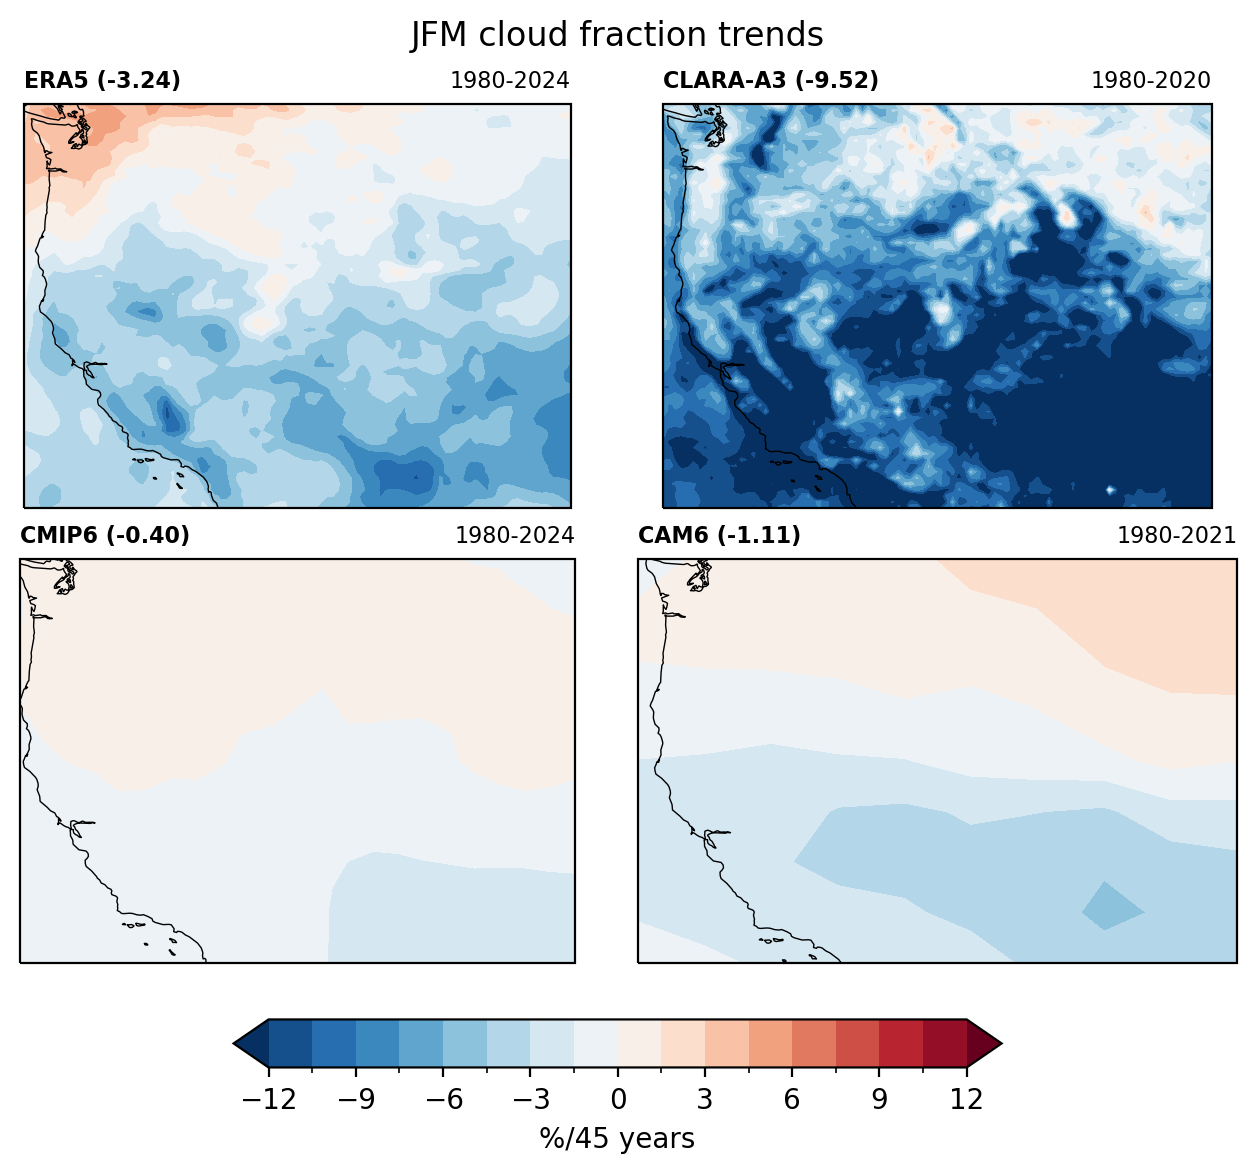

In [80]:
dss_plot = [era5_clt_jfm_trend_plot, clara_clt_jfm_trend_plot, cmip6_clt_jfm_trend_plot, cam6_clt_jfm_trend_plot]
titles_plot = ['ERA5', 'CLARA-A3', 'CMIP6', 'CAM6']

fig, ax = plt.subplots(2,2, dpi=200, layout='constrained')

for ii, ax in enumerate(ax.flatten()):
    ax = plt.subplot(2,2,ii+1,projection=ccrs.PlateCarree())
    ax.coastlines(lw=.5)
    im = dss_plot[ii].plot.contourf(vmax=12, vmin=-12, levels=17,extend='both', cmap='RdBu_r', add_colorbar=False)
    ax.set_title(f'{titles_plot[ii]} ({wus_avg_plot[ii].item():.2f})', fontsize=8, loc='left', fontweight='bold')
    ax.set_title('', loc='center',)
    ax.set_title(['1980-2024', '1980-2020', '1980-2024','1980-2021'][ii], loc='right',fontsize=8)

                      
plt.suptitle('JFM cloud fraction trends')
ax1 = fig.add_axes((.2,-.1,.6,.05))
cb = plt.colorbar(im,cax=ax1,orientation='horizontal', extend='both', label = '%/45 years')
